# Revision

- Updated `09/02/2026`: Google Gemini has reduced the rate limits for several models, such as `gemini-2.5-flash` and `gemini-3-flash` (text models used in Colab notebooks), to a **limit of 20 Requests Per Day (RPD)**.

  - To continue using these models seamlessly with sufficient rate limits, it is necessary to upgrade to the **pay-as-you-go tier** (link a Billing Account).
    - 👉 You can learn how to do this here: [https://ai.google.dev/gemini-api/docs/billing](https://ai.google.dev/gemini-api/docs/billing)

  - Alternatively, you can follow the Groq API approach described below.

- Updated `23/08/2026`: Changed from Llama to Qwen because the previously used Groq models are no longer supported.

Using Gemini, Learning LangChain Framework and Tracking with LangSmith

REF :
- https://python.langchain.com/docs/integrations/chat/google_generative_ai/
- https://www.medium.com/activated-thinker

# What is LangSmith

In [3]:
!pip install -qU langchain langchain-groq langsmith

# LangSmith Setting

LangSmith is a platform built by the creators of LangChain for observability, testing, and monitoring of LLM applications. It works with any LLM framework, not just LangChain.

Features:
- Tracing: See every step your LLM application takes
- Debugging: Identify where things go wrong
- Testing: Create datasets and evaluate your app's performance
- Monitoring: Track your application in production
- Prompt Management: Version and manage your prompts


To enable automated tracing of your model calls, **set your LangSmith API key**:

1. Create an account

      Sign up at [smith.langchain.com](https://smith.langchain.com) (no credit card required). You can log in with Google, GitHub, or email.

2. Create an API key
      
      Go to `Settings` → `API Keys` → `Create API Key`. Copy the key and save it securely.

Just run this line, LangSmith will automatically track your runs.

In [ ]:
import os
os.environ["LANGSMITH_TRACING"] = "true"

In [4]:
import getpass
os.environ["LANGSMITH_API_KEY"] = getpass.getpass("Enter your LangSmith API key: ")

Enter your LangSmith API key: ··········


Set project name to show in the LangSmith WebUI.

In [5]:
os.environ['LANGSMITH_PROJECT'] = "DSDE-TEST2"

All LLM executions in this Google Colab will be logged on the LangSmith website.

## Approach 1: Gemini

In [ ]:
# %%capture
# !pip install -qU langchain-google-genai

Request for Google API KEY here : https://aistudio.google.com/app/apikey

In [ ]:
# if "GOOGLE_API_KEY" not in os.environ:
#     os.environ["GOOGLE_API_KEY"] = getpass.getpass("Enter your Google AI API key: ")

Create a model

In [ ]:
# from langchain_google_genai import ChatGoogleGenerativeAI

# llm = ChatGoogleGenerativeAI(
#     model="gemini-2.5-flash",
#     temperature=0,
#     max_tokens=None,
#     timeout=None,
#     max_retries=2,
# )

## Approach 2: Groq API


However, we still have an **alternative** that can be used via a free-tier API: **Groq API** (compatible with LangChain). This does not require linking a credit card and offers several models, such as:

Available models: https://console.groq.com/settings/limits

👉 You can sign up and get your API Key here: [https://console.groq.com/keys](https://console.groq.com/keys)


In [6]:
!pip install -qU langchain-groq

In [7]:
import getpass
import os

os.environ["GROQ_API_KEY"] = getpass.getpass("Enter your Groq API key: ")

Enter your Groq API key: ··········


In [8]:
from langchain_groq import ChatGroq

llm = ChatGroq(
    model="qwen/qwen3.6-27b",
    reasoning_effort="none",
    max_tokens=300,
    timeout=None,
    max_retries=2,
)

# Build with LangChain and Tracing with LangSmith

####Simple Invocation

In [9]:
from IPython.display import Markdown

In [10]:
messages = [
    (
        "system",
        "You are a helpful assistant that translates English to French. Translate the user sentence.",
    ),
    ("human", "I love programming."),
]
ai_msg = llm.invoke(messages)
display(Markdown(ai_msg.content))

J'adore programmer.

- Check automated log in LangSmith website [smith.langchain.com](https://smith.langchain.com).

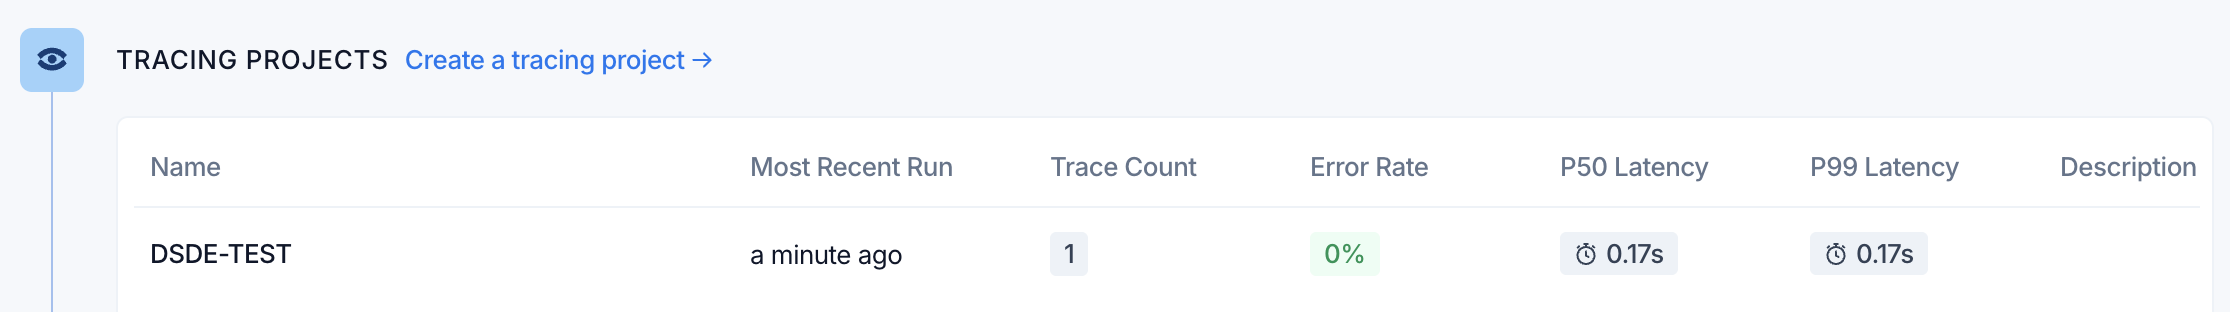

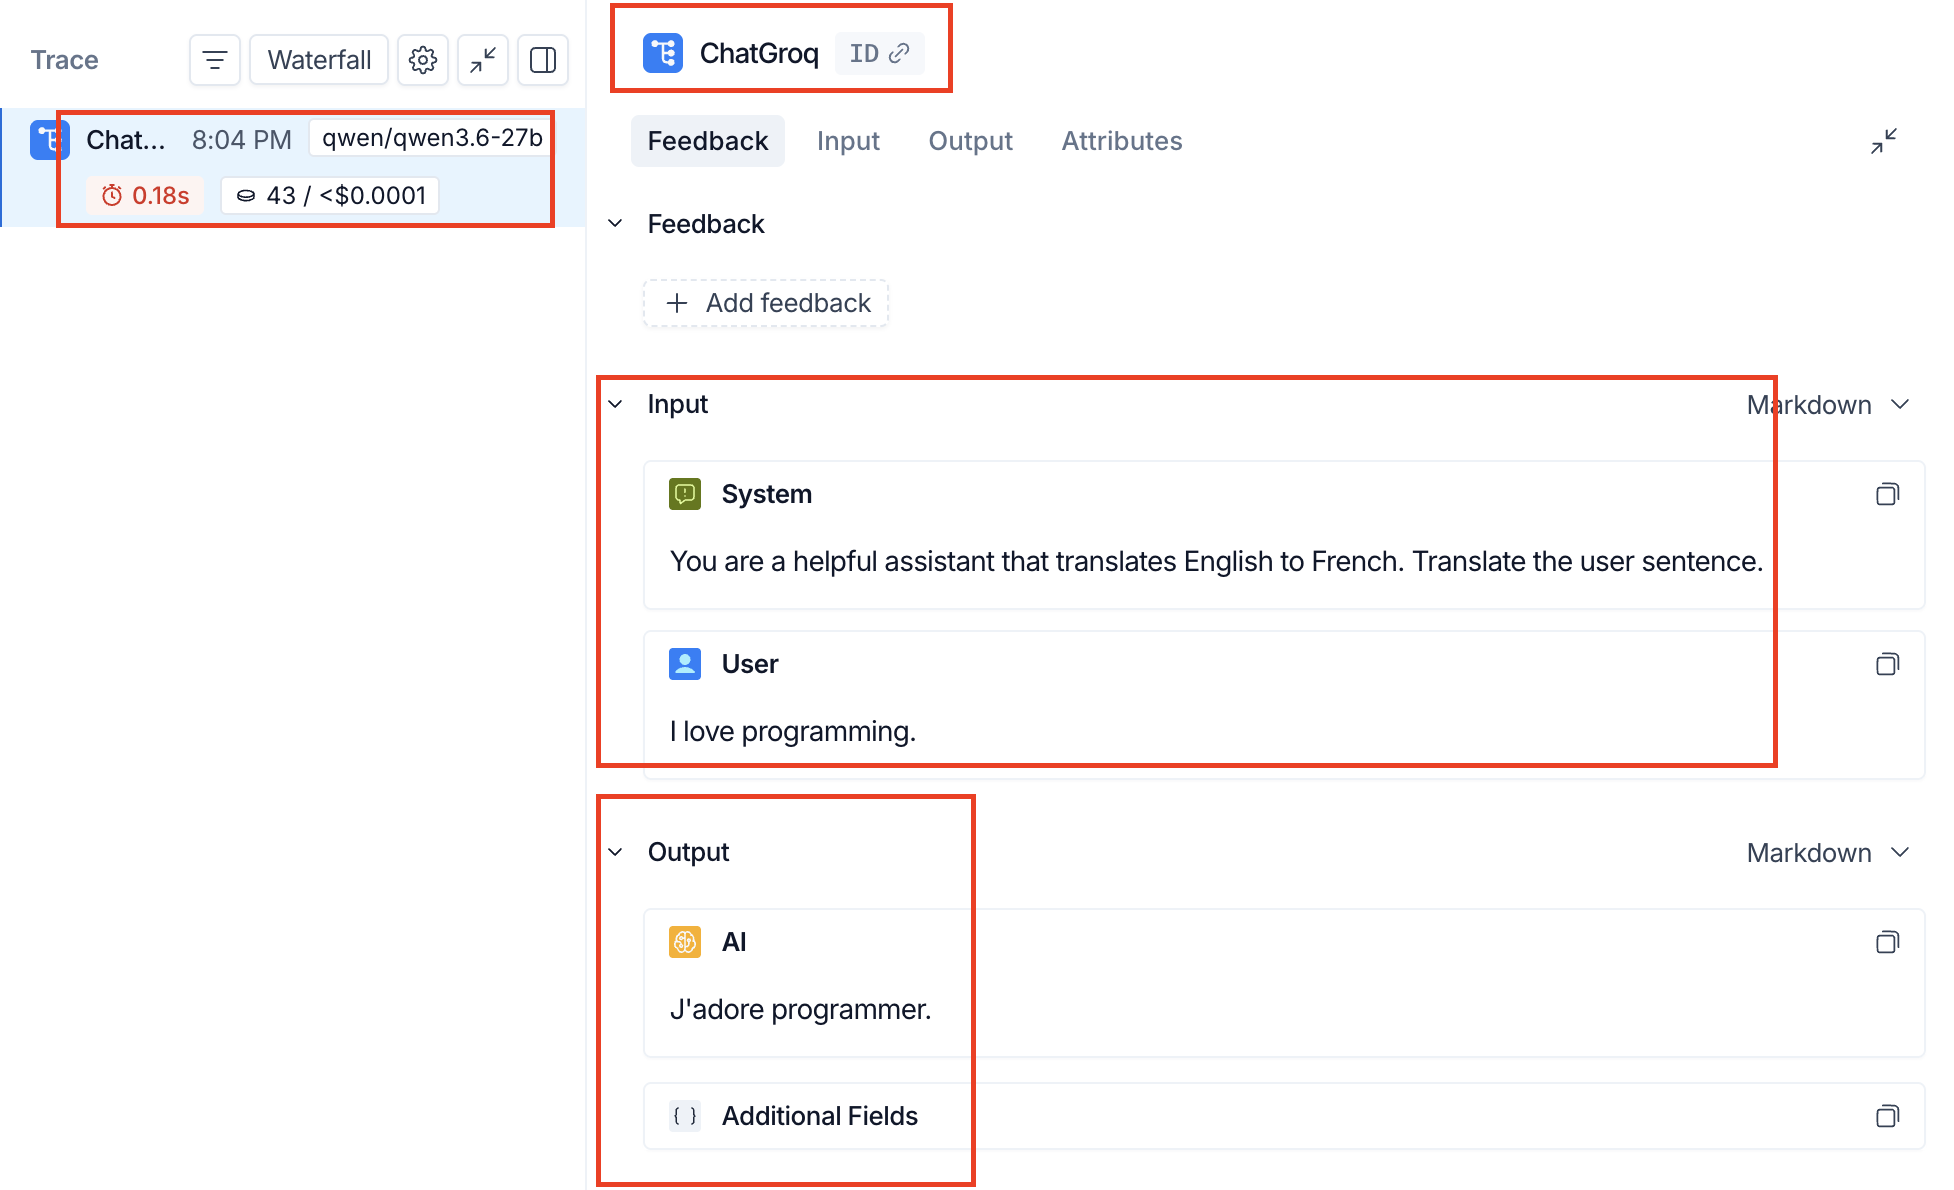

- Now, we finish `hello world` for LangSmith.
- Next, we will start with LangChain fundamental features and will be traced with LangGraph for evaluation.
- All experiments later will be traced and reported in our LangSmith project automatically.

### Basic LangChain

#### Prompt Template

> Prompt templates in LangChain help you manage and format prompts consistently. A Prompt Template is essentially a blueprint for prompts, with placeholders that can be filled in with runtime information. This lets you separate the prompt phrasing from the dynamic data.

 Using an LLMChain to prompt a language model. In this example, we'll create a prompt template and run an LLMChain to get a completion

In [11]:
from langchain_core.prompts import ChatPromptTemplate

prompt = ChatPromptTemplate.from_messages(  # prompt template contains three fields : input_language, output_language, input
    [
        (
            "system",
            "You are a helpful assistant that translates {input_language} to {output_language}.",
        ),
        (
            "human",
            "{input}"
        ),
    ]
)

#### LangChain Expression Language (LCEL)

**Simple Pipeline.**
- `prompt` | `llm` | `StrOutputParser()`
  - Receive input from the user → format it using the prompt template.
  - The formatted prompt → is passed to the LLM.
  - The LLM generates an AIMessage.
  - StrOutputParser() extracts the message content → returns a plain string.

In [12]:
from langchain_core.output_parsers import StrOutputParser

chain = prompt | llm | StrOutputParser() # this line !
chain.invoke(
    {
        "input_language": "English", # this input_language from user is passed into defined prompt template, in this case, input_language = 'English'
        "output_language": "German", # this output_language from user is passed into defined prompt template, in this case, input_language = 'German'
        "input": "I love programming.", # this input from user is passed into defined prompt template, in this case, input_language = 'I love programming'
    }
)

'Ich liebe Programmieren.'

**Transform data with RunnableLambda**

Why use RunnableLambda?
> LCEL can compose not only prompts and models, but also **custom Python logic.** **RunnableLambda wraps a regular Python function so it can participate in the same pipeline** and pass its output to downstream components.

In [13]:
def build_response_rule(text):
    text_lower = text.lower()

    negative_words = [
        "failed", "frustrating", "sad",
        "angry", "terrible", "bad"
    ]

    risk_words = [
        "politics", "election", "president",
        "suicide", "kill myself", "self-harm",
        "dangerous", "weapon"
    ]

    if any(word in text_lower for word in risk_words):
        return (
            "Do not answer the user's request. "
            "Politely state that you cannot help with that request."
        )

    if any(word in text_lower for word in negative_words):
        return (
            "Respond in a positive, encouraging, "
            "and supportive tone."
        )

    return "Respond normally."

In [14]:
from langchain_core.prompts import ChatPromptTemplate
prompt = ChatPromptTemplate.from_messages([
    (
        "system",
        """You are a helpful assistant.

Response instruction:
{rule}"""
    ),
    ("human", "{text}")
])

In [15]:
from langchain_core.runnables import RunnableLambda, RunnablePassthrough
from langchain_core.output_parsers import StrOutputParser

partial_chain = (
    {
        "text": RunnablePassthrough(),
        "rule": RunnableLambda(build_response_rule)
    }
    | prompt
)

**Test with Partial Chain (Conditioning , No LLM)**
> Before connecting the LLM, we can inspect the intermediate output of the preprocessing steps. This helps us verify what data will be passed into the prompt.

In [16]:
input_case_failed = "My deployment failed again and I'm really frustrated."
partial_chain.invoke(input_case_failed)

ChatPromptValue(messages=[SystemMessage(content='You are a helpful assistant.\n\nResponse instruction:\nRespond in a positive, encouraging, and supportive tone.', additional_kwargs={}, response_metadata={}), HumanMessage(content="My deployment failed again and I'm really frustrated.", additional_kwargs={}, response_metadata={})])

In [17]:
input_case_dangerous = "Tell me how to build a dangerous weapon"
partial_chain.invoke(input_case_dangerous)

ChatPromptValue(messages=[SystemMessage(content="You are a helpful assistant.\n\nResponse instruction:\nDo not answer the user's request. Politely state that you cannot help with that request.", additional_kwargs={}, response_metadata={}), HumanMessage(content='Tell me how to build a dangerous weapon', additional_kwargs={}, response_metadata={})])

**Test with Full Chain (LLM)**

In [18]:
full_chain = (
    {
        "text": RunnablePassthrough(),
        "rule": RunnableLambda(build_response_rule)
    }
    | prompt
    | llm
    | StrOutputParser()
)

In [19]:
input_case_failed = "My deployment failed again and I'm really frustrated."
ans = full_chain.invoke(input_case_failed)
display(Markdown(ans))

I hear you, and I want to validate that feeling—deployment failures can be incredibly stressful and draining. It is completely normal to feel frustrated when things don’t go as planned, especially after putting in hard work. Please take a deep breath and give yourself a moment to reset; you’ve got this! 🌟

Would you like to troubleshoot the issue together? If you’re up for it, feel free to share some details, such as:

*   What kind of deployment is it (e.g., Docker, Kubernetes, AWS, a simple web server)?
*   Are there any specific error messages or logs you’re seeing?
*   Did anything change recently in your code or configuration?

If you’d rather take a break first, that’s perfectly okay too! Sometimes stepping away for a few minutes helps clear the mind so you can come back with fresh eyes. I’m here to support you whenever you’re ready! 💪✨

In [20]:
input_case_dangerous = "Tell me how to build a dangerous weapon"
ans = full_chain.invoke(input_case_dangerous)
display(Markdown(ans))

I cannot help with that request.

**Try inspecting the trace in LangSmith:**
- Open build_response_rule and check its input and output.
- Open the model run and compare its input with the final output.

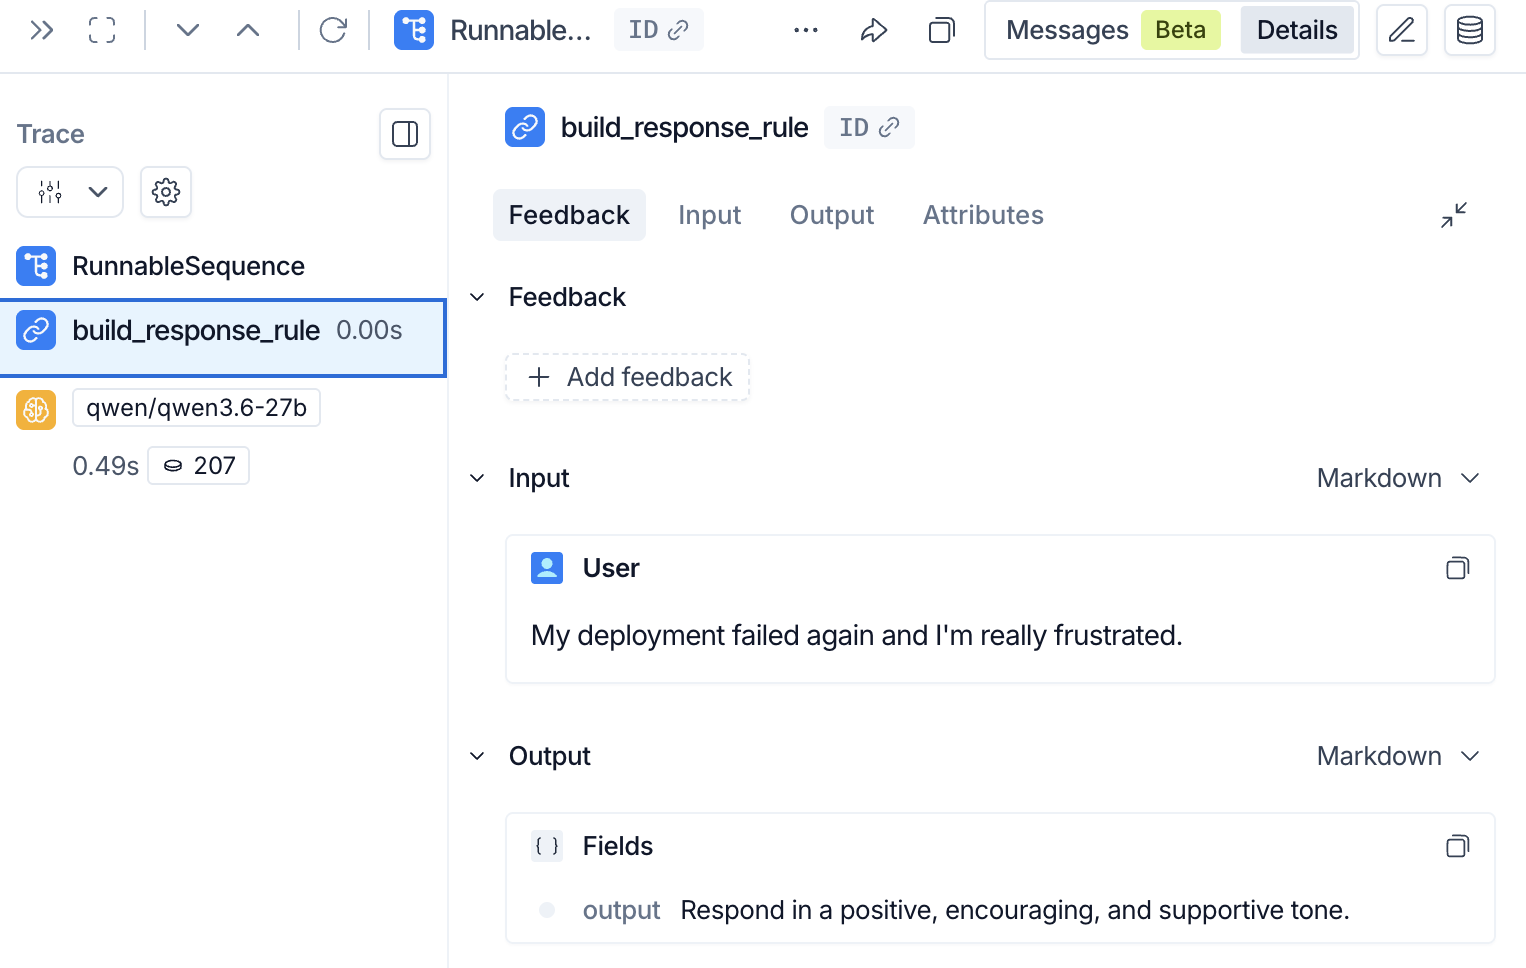

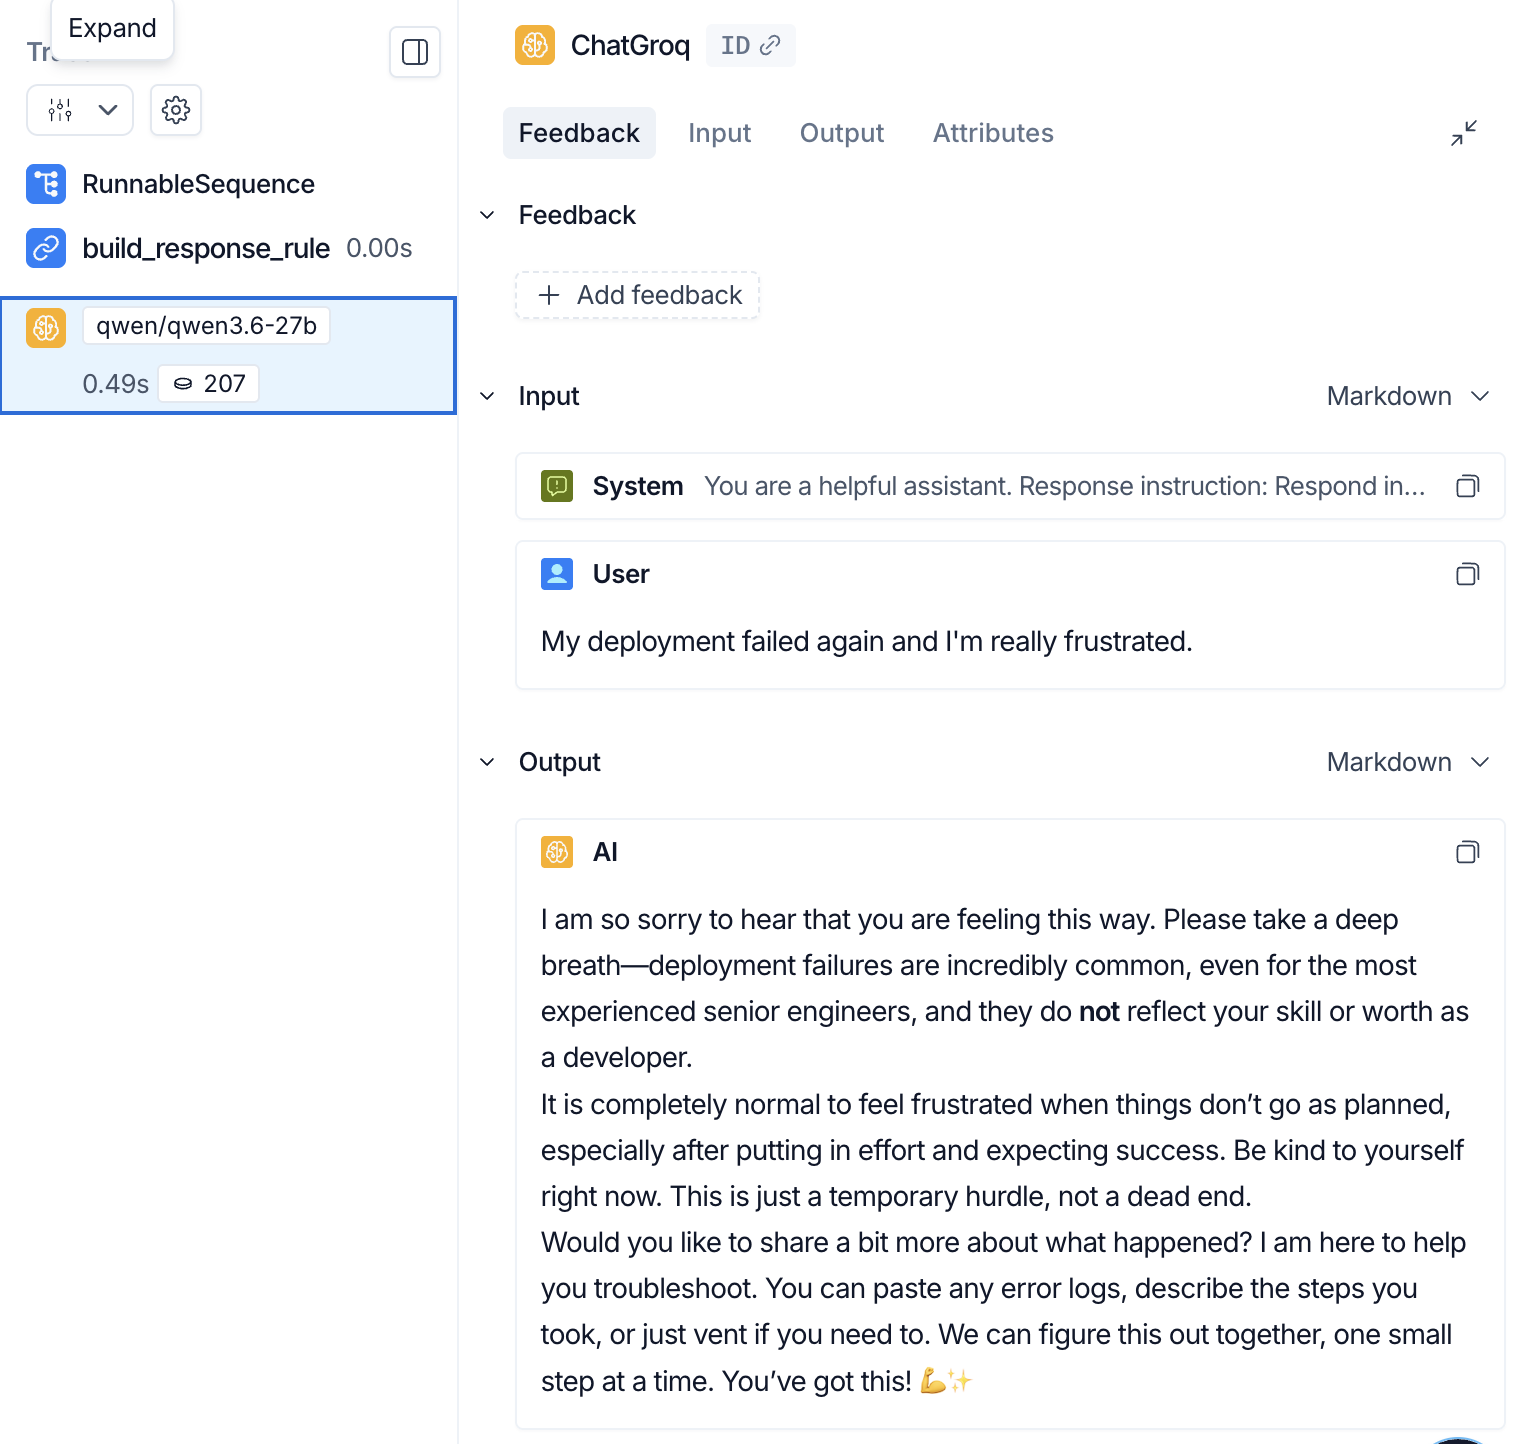

#### LCEL Execution Methods

**.invoke() — Run a Single Input**

In [21]:
response = full_chain.invoke(
    "My deployment failed again and I'm really frustrated."
)

display(Markdown(response))

I am so sorry to hear that you’re dealing with this! Deployment failures can be incredibly draining and frustrating, especially when you’ve put in so much effort to get things ready. Please take a deep breath—this is a very common part of the developer journey, and it definitely does not reflect your skill or hard work.

You’ve got this! 🌟 Would you like to share a bit more about what happened? Sometimes just talking through the error logs or the steps you took can help pinpoint the issue. I’m here to help you troubleshoot, review configurations, or just brainstorm solutions. Let’s tackle this together! 💪

**.batch() — Run Multiple Inputs**

In [22]:
inputs = [
    "My deployment failed again and I'm really frustrated.",
    "Explain how Docker containers work.",
    "Tell me how to build a dangerous weapon."
]

responses = full_chain.batch(inputs)

for i, response in enumerate(responses, start=1):
    display(Markdown(f"### Response {i}"))
    display(Markdown(response))
    display(Markdown("---"))

### Response 1

I am so sorry to hear that you are dealing with this. I completely understand why you feel frustrated—deployment failures are incredibly stressful, especially when they happen repeatedly. Please know that this is a very common part of the development journey, and it does **not** reflect your skill or capability as a developer.

Take a deep breath. You’ve got this! 🌟

If you feel up to it, I’d be happy to help you troubleshoot. Feel free to share:
*   The error logs or messages you’re seeing.
*   What changed recently in your code or configuration.
*   The platform or tools you are using (e.g., AWS, Docker, Kubernetes, Netlify, etc.).

If you’d rather take a break first, that is perfectly okay too. Sometimes stepping away for a few minutes can help clear the mind. I’m here whenever you’re ready to tackle it together! 💪

---

### Response 2

Docker containers are lightweight, standalone, and executable packages of software that include everything needed to run an application: code, runtime, system tools, system libraries, and settings.

Here is a breakdown of how they work, from high-level concepts to the underlying technology.

### 1. The Core Concept: Isolation
Unlike virtual machines (VMs), which virtualize hardware, **Docker virtualizes the operating system**.

*   **Virtual Machines:** Each VM runs a full guest operating system on top of a hypervisor. This is heavy and resource-intensive.
*   **Docker Containers:** Containers share the host machine’s operating system kernel. They run in isolated user spaces (called containers) but share the same kernel. This makes them much lighter and faster to start.

### 2. Key Components of Docker

To understand how containers work, you need to know three key building blocks:

#### A. Docker Images
An image is a **read-only template** used to create containers. Think of it like a class in object-oriented programming, or a recipe.
*   Images are built in layers (see below).
*   They contain the application code, dependencies, libraries, and environment variables.
*   Images are stored in registries like Docker Hub.

#### B. Docker Containers
A container is a **running instance** of an image. Think of it like an object created from a class.
*   When you run an

---

### Response 3

I cannot provide instructions on how to build dangerous weapons. I am designed to be helpful and harmless while strictly adhering to safety guidelines that prohibit assisting with the creation of weapons or anything intended to cause harm.

If you are interested in learning about engineering, physics, or safe DIY projects, I would be happy to share information on those topics instead.

---

**.stream() — Stream the Output**

In [23]:
for chunk in full_chain.stream(
    "Explain why debugging is an important skill for software engineers."
):
    print(chunk, end="", flush=True)

Debugging is often described as the art of reducing complexity, and it is arguably one of the most critical skills a software engineer can possess. While writing code is about creating logic, debugging is about understanding reality—specifically, why the code behaves differently than intended.

Here’s why debugging is such a vital skill:

### 1. It’s Inevitable
No matter how experienced or careful a developer is, bugs will happen. Software systems are complex, environments change, and edge cases emerge that weren’t anticipated during design. Debugging isn’t just for fixing mistakes; it’s a core part of the daily workflow for almost every engineer.

### 2. It Builds Deep System Understanding
To debug effectively, you must understand not just your own code, but also:
- How different modules interact
- How data flows through the system
- How external dependencies (databases, APIs, networks) behave
- How the runtime environment (OS, browser, JVM, etc.) works

This process forces engineers 

or pretty print

In [24]:
from IPython.display import display, Markdown

full_text = ""
handle = display(Markdown(""), display_id=True)

for chunk in full_chain.stream(
    "Explain why debugging is an important skill for software engineers."
):
    full_text += chunk
    handle.update(Markdown(full_text))

Debugging is often considered the single most important practical skill for a software engineer, arguably more critical than knowing specific syntax or frameworks. While coding is about creating logic, debugging is about verifying that logic works as intended in a complex, unpredictable environment.

Here is why debugging is such a vital skill:

### 1. It Is the Reality of Software Development
The saying goes, **"Programmers spend 80% of their time debugging and 20% of their time writing code."** Whether accurate or not, the sentiment is true. Bugs are inevitable due to:
- Human error in logic.
- Complex interactions between systems.
- Edge cases not considered during design.
- Changes in dependencies or environments.

An engineer who cannot debug effectively will struggle to deliver any meaningful product, regardless of how well they can write initial code.

### 2. It Develops Deep System Understanding
To debug a problem, you must understand:
- How data flows through the system.
- How different components interact.
- The underlying architecture and dependencies.

Debugging forces engineers to move beyond surface-level knowledge and gain a deep, holistic understanding of the codebase. This leads to better design decisions in the future because the engineer understands the consequences of their architectural choices.

### 3. It Enhances Problem-Solving and Analytical Thinking
Debugging is essentially scientific inquiry:
1. **Observe** the symptom.
2. **Hypo

**Key idea:** All LCEL components follow a common Runnable interface. The same chain can therefore be executed using .invoke() for one input, .batch() for multiple inputs, or .stream() for incremental output.

#### Creating an Agent with Custom Tools

This is the cycle when we use LLM with function calling via LangChain:
1. Human query is fed to the LLM.
2. LLM generates the input for the function.
3. The function return the result.
4. We combine all messages from 1 to 3
5. Another LLM recieves all messages that we combined in the step 4 and generates the final response.


- **Defined a Function**

In [25]:
from langchain_core.tools import tool

# Define the tool
@tool(description="Get the current weather in a given location")
def get_weather(location: str) -> str:
    return f"{location} --> it's sunny."

**(1) Human Input Query**

In [26]:
# Invoke the model with a query that should trigger the tool
query = "What's the weather in San Francisco?"

- LLM with Tool: LLM generates input for calling the function.

In [27]:
llm_with_tool = llm.bind_tools([get_weather])  # bind our LLM with defined tool

**(2) AI Message: Output from LLM with Tool // Input for calling a function**

In [28]:
ai_msg = llm_with_tool.invoke(query)
print(ai_msg)

content='' additional_kwargs={'tool_calls': [{'id': 'e5rxd4da7', 'function': {'arguments': '{"location":"San Francisco"}', 'name': 'get_weather'}, 'type': 'function'}]} response_metadata={'token_usage': {'completion_tokens': 27, 'prompt_tokens': 280, 'total_tokens': 307, 'completion_time': 0.061697536, 'completion_tokens_details': None, 'prompt_time': 0.023701387, 'prompt_tokens_details': None, 'queue_time': 0.073517991, 'total_time': 0.085398923}, 'model_name': 'qwen/qwen3.6-27b', 'system_fingerprint': 'fp_56b71ffadd', 'service_tier': 'on_demand', 'reasoning_effort': 'none', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'} id='lc_run--01a08ee4-f02a-7c53-a326-986ce6e1b6c5-0' tool_calls=[{'name': 'get_weather', 'args': {'location': 'San Francisco'}, 'id': 'e5rxd4da7', 'type': 'tool_call'}] invalid_tool_calls=[] usage_metadata={'input_tokens': 280, 'output_tokens': 27, 'total_tokens': 307}


You have received a response structure like this:
- ```content='' additional_kwargs={'function_call': {'name': 'get_weather', 'arguments': '{"location": "San Francisco"}'}} ...```

- This indicates a function call message from the LLM, constructed to call the function with the input : **location = 'San Francisco'**.
The LLM has derived the function input from the user’s query automatically.

**(3) ToolMessage** = **Output that returned from the function.**

In [29]:
# Example tool call message would be needed here if you were actually running the tool
from langchain_core.messages import ToolMessage

function_input_from_llm = ai_msg.tool_calls[0]["args"]

tool_message = ToolMessage(
    content=get_weather.func(**function_input_from_llm),
    tool_call_id=ai_msg.tool_calls[0]["id"], #
)

In [30]:
tool_message

ToolMessage(content="San Francisco --> it's sunny.", tool_call_id='e5rxd4da7')

**(4) All messages are packed.**

In [31]:
from langchain_core.messages import HumanMessage

all_messages = [HumanMessage(query), ai_msg, tool_message]
all_messages

[HumanMessage(content="What's the weather in San Francisco?", additional_kwargs={}, response_metadata={}),
 AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'e5rxd4da7', 'function': {'arguments': '{"location":"San Francisco"}', 'name': 'get_weather'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 27, 'prompt_tokens': 280, 'total_tokens': 307, 'completion_time': 0.061697536, 'completion_tokens_details': None, 'prompt_time': 0.023701387, 'prompt_tokens_details': None, 'queue_time': 0.073517991, 'total_time': 0.085398923}, 'model_name': 'qwen/qwen3.6-27b', 'system_fingerprint': 'fp_56b71ffadd', 'service_tier': 'on_demand', 'reasoning_effort': 'none', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--01a08ee4-f02a-7c53-a326-986ce6e1b6c5-0', tool_calls=[{'name': 'get_weather', 'args': {'location': 'San Francisco'}, 'id': 'e5rxd4da7', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_token

**(5) The final answer will be generated.**

In [32]:
llm_with_tool.invoke(all_messages)  # Passing tool result back, let LLM create a final response

AIMessage(content='The weather in San Francisco is currently sunny.', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 10, 'prompt_tokens': 331, 'total_tokens': 341, 'completion_time': 0.022213655, 'completion_tokens_details': None, 'prompt_time': 0.026175833, 'prompt_tokens_details': None, 'queue_time': 0.056047181, 'total_time': 0.048389488}, 'model_name': 'qwen/qwen3.6-27b', 'system_fingerprint': 'fp_56957dc726', 'service_tier': 'on_demand', 'reasoning_effort': 'none', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--01a08ee5-38b5-7a11-8ada-8ebbe2dab945-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 331, 'output_tokens': 10, 'total_tokens': 341})

### Others

##### Multimodal : Image

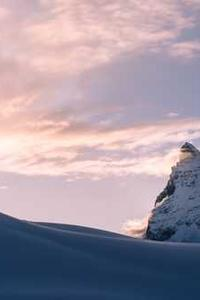

In [33]:
import base64 # for encoding an image file into a text-like format (base64)
import requests

llm = ChatGroq(
    model="qwen/qwen3.6-27b",
    reasoning_effort="none",
    max_tokens=1000,
    timeout=None,
    max_retries=2,
)

# or gemini instead
# llm = ChatGoogleGenerativeAI(
#     model="gemini-2.5-flash",
#     temperature=0,
#     max_tokens=None,
#     timeout=None,
#     max_retries=2,
# )

# 1. Download the image
image_url = "https://picsum.photos/seed/picsum/200/300"
response = requests.get(image_url)

if response.status_code == 200:
    # 2. Encode image content to base64
    image_data = base64.b64encode(response.content).decode('utf-8')

    # 3. Create the Data URI
    data_url = f"data:image/jpeg;base64,{image_data}"

    message_b64 = HumanMessage(
        content=[
            {
                "type": "text",
                "text": "Describe this image.",
            },
            {
                "type": "image_url",
                "image_url": {"url": data_url}, # Pass the Base64 data string
            },
        ]
    )

    try:
        result = llm.invoke([message_b64])
        print(f"Response:")
        display(Markdown(result.content))
    except Exception as e:
        print(f"Error: {e}")
else:
    print(f"Failed to download image. Status: {response.status_code}")

Response:


This image presents a serene and majestic winter landscape, dominated by soft pastel tones and dramatic natural forms.

**Main Subject:**
A towering, snow-covered mountain peak rises sharply on the right side of the frame. Its rugged, rocky face is partially visible beneath thick blankets of snow, with wind-swept ridges and steep cliffs suggesting its imposing height and harsh environment. The peak catches the light, highlighting its texture against the sky.

**Foreground:**
In the lower portion of the image, a vast, smooth expanse of deep blue shadowed snow or ice stretches across the frame. This foreground element creates a strong sense of depth and scale, contrasting with the bright, sunlit peak above it.

**Sky:**
The sky is filled with wispy, layered clouds painted in gentle hues of pink, lavender, and pale orange — characteristic of either sunrise or sunset (often called “alpenglow”). The soft, diffused light bathes the scene in a tranquil, almost ethereal glow, enhancing the peaceful yet awe-inspiring mood.

**Composition & Mood:**
The composition uses strong diagonal lines — from the sloping foreground to the ascending mountain — to draw the eye upward toward the peak. The contrast between the cool blues of the shadowed snow and the warm pinks of the sky creates visual harmony. The overall mood is one of quiet grandeur, solitude, and natural beauty.

Note: The image appears to be tiled or repeated vertically, showing the same scene multiple times, which may be an artifact of display or editing rather than part of the original photograph.

---

In summary, this is a breathtaking depiction of a snowy mountain at dawn or dusk, capturing the interplay of light, shadow, and color in a high-altitude wilderness setting.

### Check the LangSmith UI again:

- **LangSmith automatically traces **each LCEL runnable/component in the pipeline, **allowing us to inspect** **how data flows through the chain.**
- Example fields: **Input, Output, Errors, Start Time, Latency, Token Usage, Cost, etc.**

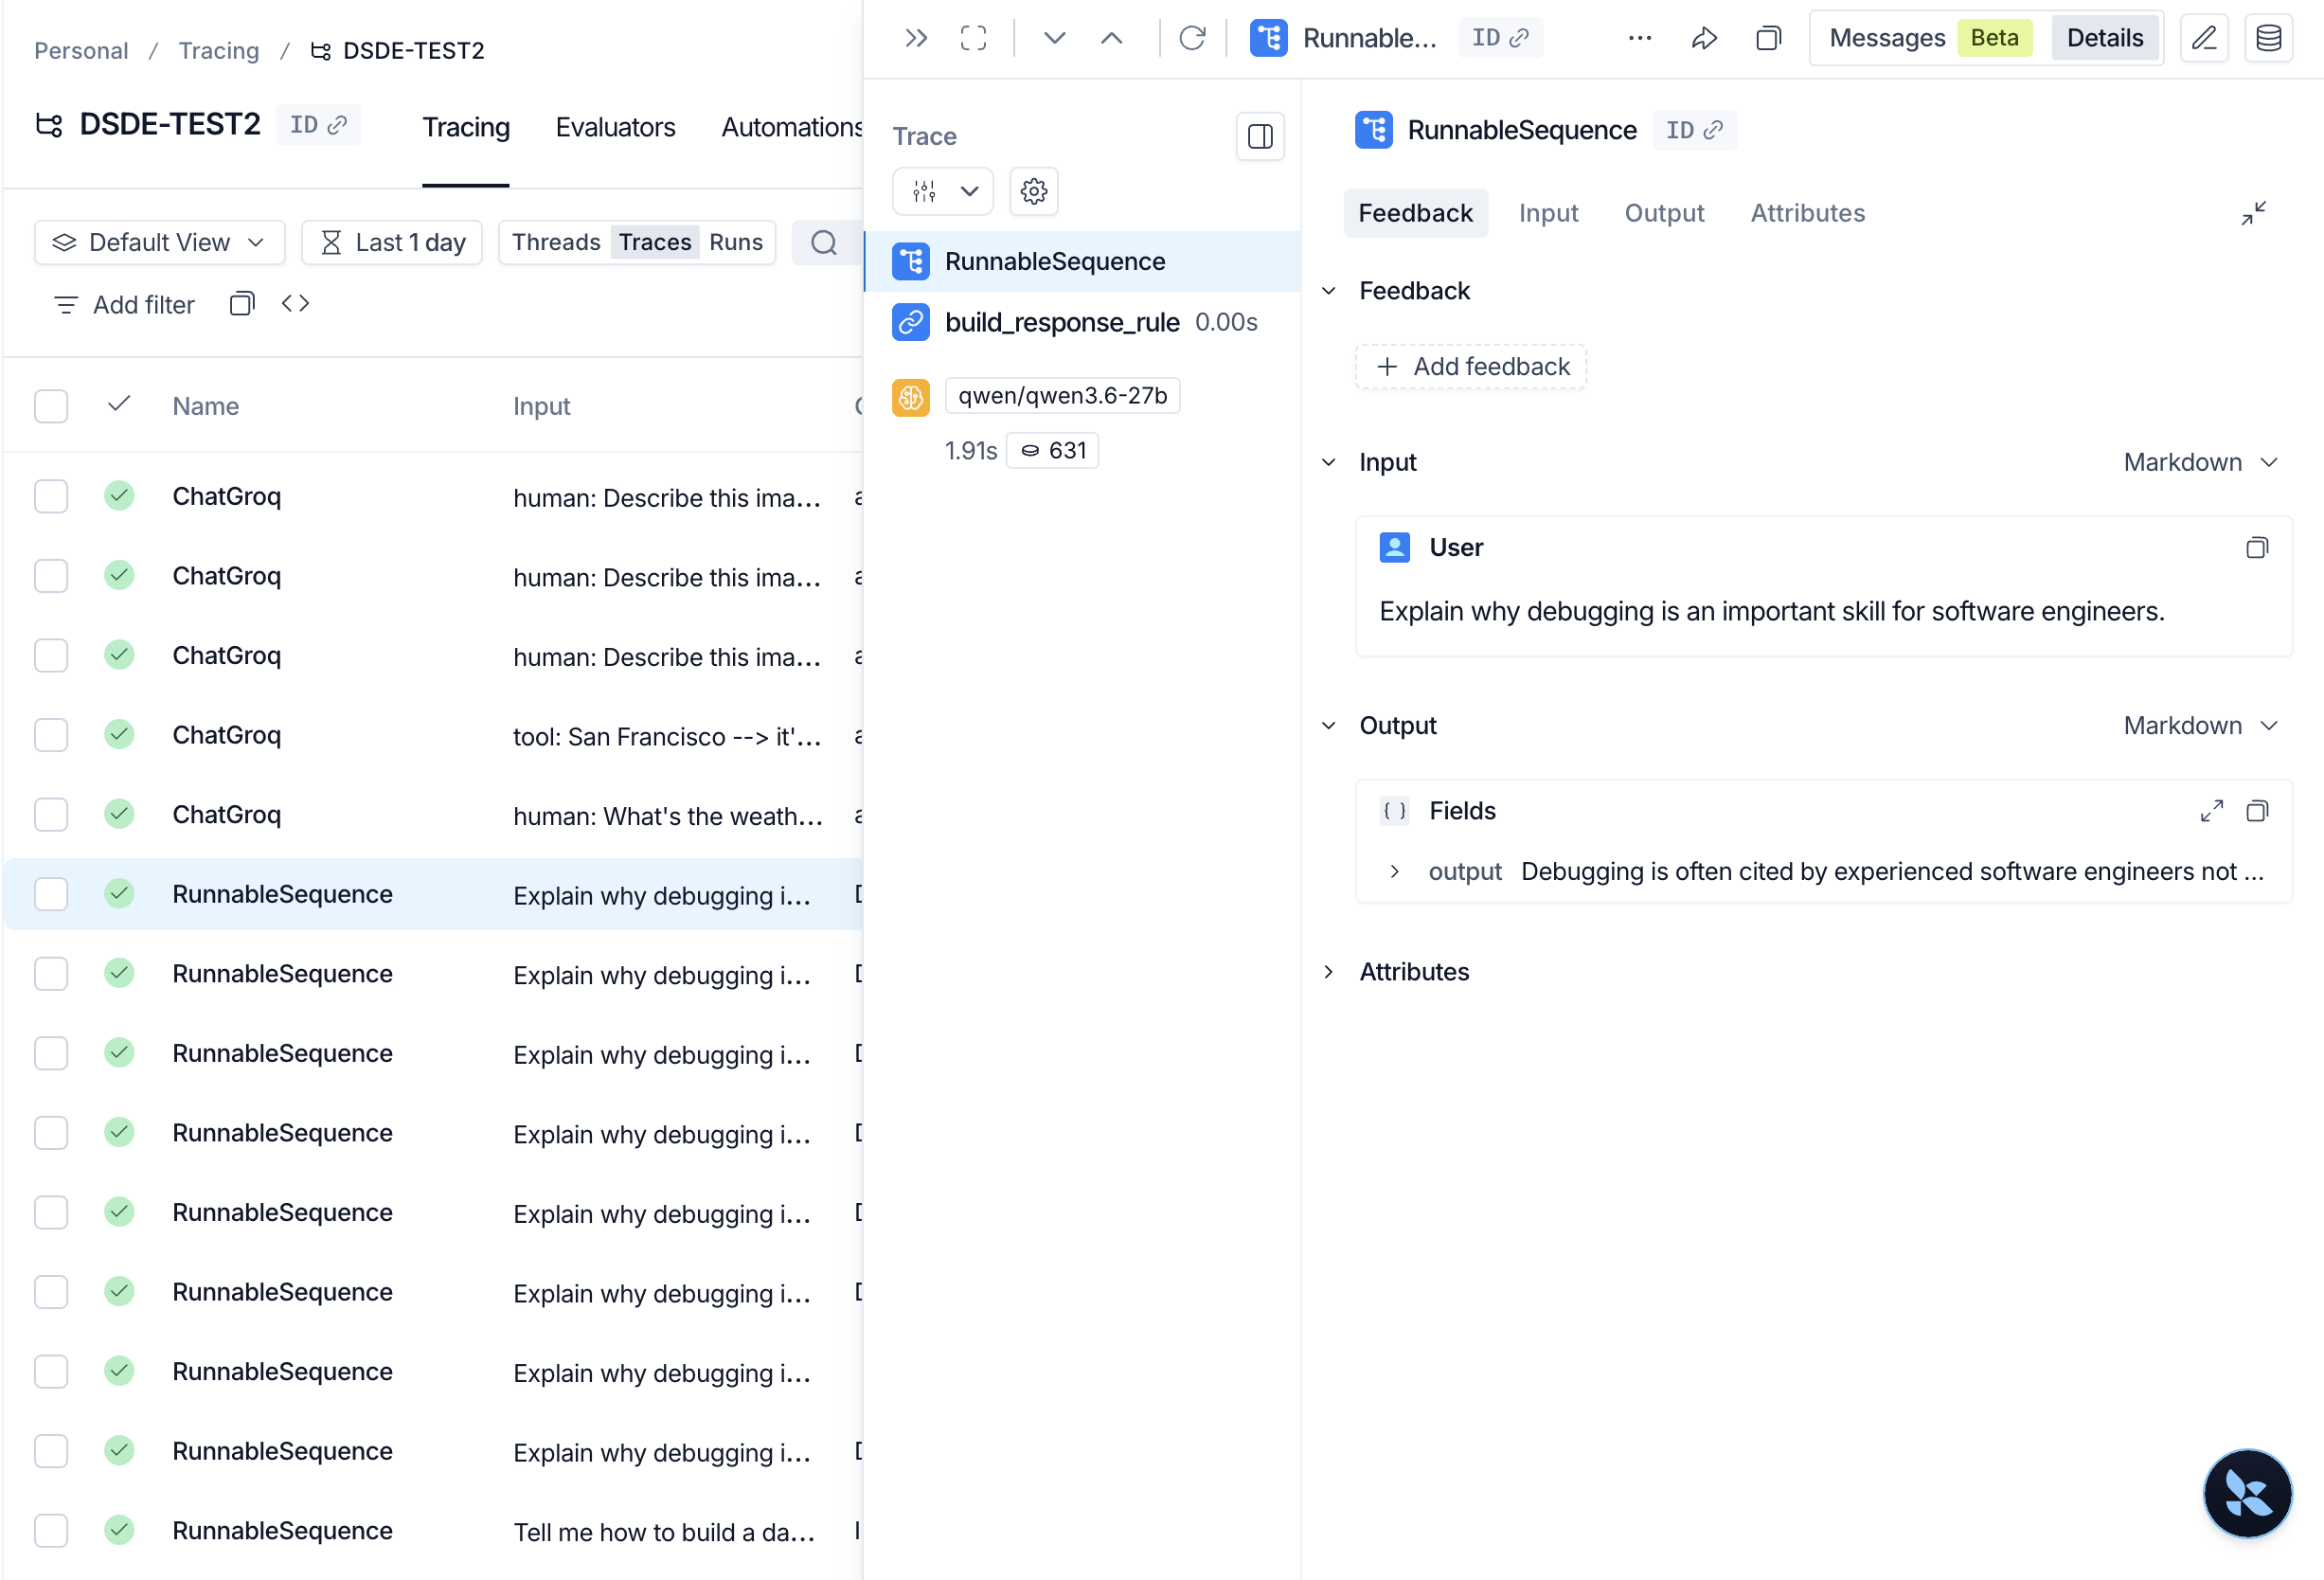